In [100]:
!pip install geopandas contextily

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import geopandas as gpd
import contextily as cx
from matplotlib import pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [102]:
kc = pd.read_csv('kc_house_data.csv')
futu = pd.read_csv('future_unseen_examples.csv')
demo = pd.read_csv('zipcode_demographics.csv')

print(f'Tamanho da tabela de casas: {kc.shape}')
print(f'Tamanho da tabela de exemplos futuros: {futu.shape}')
print(f'Tamanho da tabela de demografia: {demo.shape}')

kc.head()

Tamanho da tabela de casas: (21613, 21)
Tamanho da tabela de exemplos futuros: (100, 18)
Tamanho da tabela de demografia: (70, 27)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [103]:
# Os dados físicos dos imóveis foram combinados com os dados demográficos usando a variável zipcode.
# Essa variável representa a região do imóvel. Dessa forma, cada casa passou a ter tanto suas
# características próprias, como área, número de quartos e qualidade construtiva, quanto informações da
# região onde está localizada, como renda mediana, valor médio das casas e nível educacional.
df = kc.merge(demo, on="zipcode", how="left")

df_future = futu.merge(demo, on="zipcode", how="left")
df.drop(['id', 'date', 'zipcode'], axis = 1, inplace = True)
print(df.shape)
df.head()

(21613, 44)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0.0,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.0,0.0,0.0,2.0,5.0,15.0,20.0,5.0,20.0,12.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0.0,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0.0,0.0,0.0,1.0,3.0,13.0,20.0,7.0,25.0,12.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.0,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5


| Variável | Descrição |
|---|---|
| `price` | Preço de venda do imóvel, variável alvo do modelo. |
| `id` | Identificador único do imóvel. |
| `date` | Data de venda do imóvel. |
| `bedrooms` | Quantidade de quartos. |
| `bathrooms` | Quantidade de banheiros. |
| `sqft_living` | Área habitável da casa. |
| `sqft_lot` | Área total do terreno. |
| `floors` | Número de andares. |
| `waterfront` | Indica se o imóvel fica à beira d’água. |
| `view` | Qualidade ou quantidade de vista do imóvel. |
| `condition` | Estado de conservação da casa. |
| `grade` | Qualidade geral da construção e acabamento. |
| `sqft_above` | Área construída acima do nível do solo. |
| `sqft_basement` | Área do porão. |
| `yr_built` | Ano de construção do imóvel. |
| `yr_renovated` | Ano da última reforma. |
| `zipcode` | Código postal da região. |
| `lat` | Latitude do imóvel. |
| `long` | Longitude do imóvel. |
| `sqft_living15` | Área habitável média dos 15 imóveis mais próximos. |
| `sqft_lot15` | Área média do terreno dos 15 imóveis mais próximos. |


## Combinação dos dados físicos e demográficos

Para a construção do modelo de previsão de preços, foram combinadas informações físicas do imóvel com variáveis relacionadas à localização e ao contexto da vizinhança. Essa combinação é importante porque o valor de uma casa não depende apenas de suas características estruturais, mas também da região em que ela está localizada.

Os dados físicos representam as características próprias do imóvel, como quantidade de quartos, banheiros, área construída, área do terreno, número de andares, condição de conservação, qualidade da construção, presença de porão, ano de construção e ano de reforma. Essas variáveis ajudam o modelo a entender o tamanho, o conforto, o estado e o padrão construtivo da residência.

Já os dados demográficos ou regionais foram representados principalmente pelas variáveis de localização e vizinhança, como `zipcode`, `lat`, `long`, `sqft_living15` e `sqft_lot15`. O `zipcode` indica a região ou código postal do imóvel, enquanto `lat` e `long` representam sua posição geográfica. As variáveis `sqft_living15` e `sqft_lot15` indicam características médias dos imóveis próximos, funcionando como uma forma de representar o padrão da vizinhança.

Dessa forma, o conjunto de dados final reuniu atributos internos da casa e informações externas relacionadas à sua localização. Por exemplo, dois imóveis com a mesma área construída podem ter preços diferentes dependendo do bairro, da proximidade com áreas valorizadas, da vista, da região e do padrão das casas ao redor.

No pré-processamento, essas variáveis foram mantidas no mesmo DataFrame para que o modelo pudesse aprender relações entre estrutura física, localização e contexto regional. Assim, o modelo não considera apenas o imóvel isoladamente, mas também o ambiente em que ele está inserido, tornando a previsão mais completa e realista.

É importante destacar que não foi realizado um cruzamento com uma base demográfica externa. Neste projeto, as informações demográficas foram aproximadas por variáveis geográficas e de vizinhança presentes no próprio dataset, como localização, código postal e características dos imóveis próximos.

In [104]:
df.isnull().sum().sort_values(ascending=False)

price                     0
bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
yr_renovated              0
lat                       0
long                      0
sqft_living15             0
sqft_lot15                0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
hous_val_amt              0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_prfsnl_qty          0
per_urbn                  0
per_sbrbn                 0
per_farm            

Após a união dos datasets, não foram encontrados valores ausentes relevantes, indicando que todos os zipcodes do dataset de casas possuem informações demográficas correspondentes.

In [105]:
# Atualizando colunas de ano
# a variável 'yr_built' é transformada na variável 'years', que representa a idade do imóvel em relação ao ano de referência. Depois disso, a coluna original de ano de construção é removida.

df['years'] = 2026 - df['yr_built']
df.drop('yr_built', axis = 1, inplace = True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0,71
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.0,0.0,2.0,5.0,15.0,20.0,5.0,20.0,12.0,75
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0,93
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0.0,0.0,1.0,3.0,13.0,20.0,7.0,25.0,12.0,61
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5,39


In [106]:
# Ajustando a reforma
# a variável 'yr_renovated' é transformada em 'yrs_renovated', representando há quantos anos o imóvel foi reformado. Imóveis sem reforma recebem valor zero.

df['yrs_renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 2026 - x)
df.drop('yr_renovated', axis = 1, inplace = True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0,71,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.0,2.0,5.0,15.0,20.0,5.0,20.0,12.0,75,35
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0,93,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0.0,1.0,3.0,13.0,20.0,7.0,25.0,12.0,61,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5,39,0


In [107]:
# Ajustando bedrooms e bathrooms
# é criada a variável 'bedrooms_per_bathroom', que representa a quantidade de quartos por banheiro. Essa variável ajuda a medir a proporção de conforto do imóvel.

df['bedrooms_per_bathroom'] = df['bedrooms'] / df['bathrooms'].replace(0, np.nan)
df['bedrooms_per_bathroom'] = df['bedrooms_per_bathroom'].replace(np.nan, 0)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated,bedrooms_per_bathroom
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,4.0,8.0,20.0,21.0,5.0,12.0,4.0,71,0,3.000000
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,2.0,5.0,15.0,20.0,5.0,20.0,12.0,75,35,1.333333
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,1.0,4.0,13.0,20.0,6.0,19.0,9.0,93,0,2.000000
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1.0,3.0,13.0,20.0,7.0,25.0,12.0,61,0,1.333333
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1.0,5.0,15.0,19.0,5.0,19.0,7.5,39,0,1.500000


In [108]:
# Ajuste da variável de vista
# Nesta célula o valor original da variável 'view' é preservado em 'view_qtde', enquanto 'view' é convertida em uma variável binária, indicando apenas se o imóvel possui ou não vista.

df['view_qtde'] = df['view']
df['view'] = df['view'].apply(lambda x: 0 if x == 0 else 1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated,bedrooms_per_bathroom,view_qtde
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,8.0,20.0,21.0,5.0,12.0,4.0,71,0,3.000000,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,5.0,15.0,20.0,5.0,20.0,12.0,75,35,1.333333,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,4.0,13.0,20.0,6.0,19.0,9.0,93,0,2.000000,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,3.0,13.0,20.0,7.0,25.0,12.0,61,0,1.333333,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,5.0,15.0,19.0,5.0,19.0,7.5,39,0,1.500000,0


In [109]:
# Adicionando area total
# é criada a variável 'sqft_total', somando a área habitável com a área do terreno. Essa nova variável representa uma medida geral do tamanho da propriedade.

df['sqft_total'] = df['sqft_living'] + df['sqft_lot']
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated,bedrooms_per_bathroom,view_qtde,sqft_total
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,20.0,21.0,5.0,12.0,4.0,71,0,3.000000,0,6830
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,15.0,20.0,5.0,20.0,12.0,75,35,1.333333,0,9812
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,13.0,20.0,6.0,19.0,9.0,93,0,2.000000,0,10770
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,13.0,20.0,7.0,25.0,12.0,61,0,1.333333,0,6960
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,15.0,19.0,5.0,19.0,7.5,39,0,1.500000,0,9760


In [110]:
# Condição baixa
# é criada a variável 'condicao_baixa', que indica se o imóvel possui uma condição de conservação considerada baixa, com base na coluna 'condition'.

df['condicao_baixa'] = df.apply(lambda row: 1 if row['condition'] <= 2 else 0, axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated,bedrooms_per_bathroom,view_qtde,sqft_total,condicao_baixa
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,21.0,5.0,12.0,4.0,71,0,3.000000,0,6830,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,20.0,5.0,20.0,12.0,75,35,1.333333,0,9812,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,20.0,6.0,19.0,9.0,93,0,2.000000,0,10770,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,20.0,7.0,25.0,12.0,61,0,1.333333,0,6960,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,19.0,5.0,19.0,7.5,39,0,1.500000,0,9760,0


In [111]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_some_clg,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated,bedrooms_per_bathroom,view_qtde,sqft_total,condicao_baixa
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.098274,3.409430,7.656873,...,18.678295,5.131634,19.413640,8.838754,54.994864,1.275991,1.750605,0.234303,1.718687e+04,0.009346
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.297692,0.650743,1.175459,...,2.789687,0.780764,7.048811,5.094015,29.373411,6.858984,0.665200,0.766318,4.158908e+04,0.096225
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,11.000000,2.000000,6.000000,2.000000,11.000000,0.000000,0.000000,0.000000,1.423000e+03,0.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,17.000000,5.000000,13.000000,4.000000,29.000000,0.000000,1.333333,0.000000,7.035000e+03,0.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,19.000000,5.000000,19.000000,7.500000,51.000000,0.000000,1.600000,0.000000,9.575000e+03,0.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,20.000000,6.000000,25.000000,12.000000,75.000000,0.000000,2.000000,0.000000,1.300000e+04,0.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,1.000000,5.000000,13.000000,...,34.000000,7.000000,39.000000,24.000000,126.000000,92.000000,18.857143,4.000000,1.652659e+06,1.000000


| Variável ajustada | Descrição |
|---|---|
| `log_price` | Transformação logarítmica de `price`, usada para reduzir a assimetria da variável alvo. |
| `years` | Idade do imóvel, calculada a partir de `yr_built`. |
| `yrs_renovated` | Tempo desde a última reforma, calculado a partir de `yr_renovated`. |
| `bedrooms_per_bathroom` | Razão entre quartos e banheiros. |
| `view_qtde` | Valor original da variável `view`, antes da transformação binária. |
| `view` | Variável ajustada para indicar apenas presença ou ausência de vista. |
| `sqft_total` | Soma entre área habitável e área do terreno. |
| `condicao_baixa` | Indica se o imóvel possui condição baixa de conservação. |


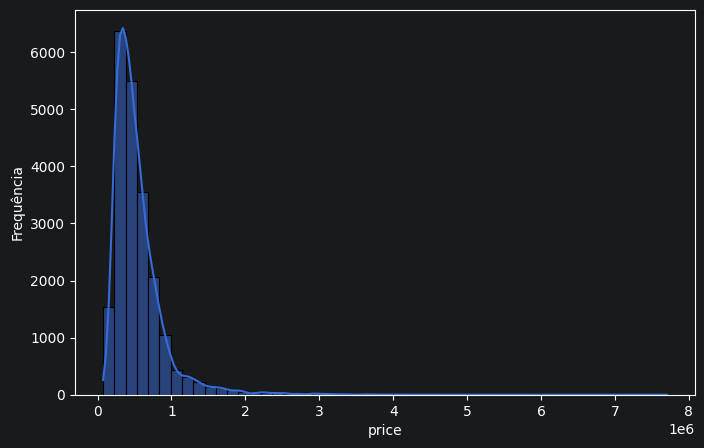

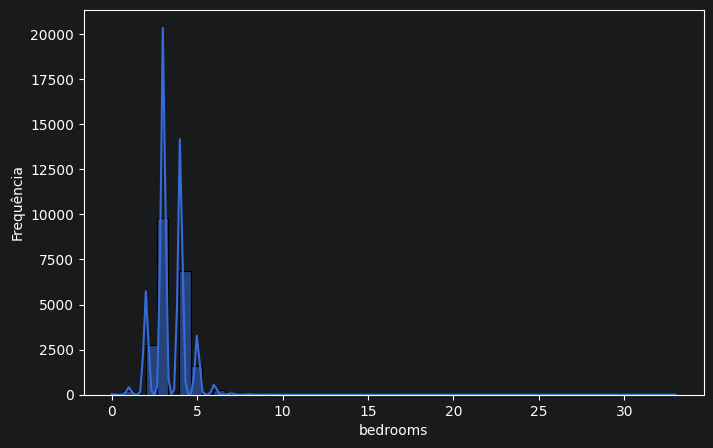

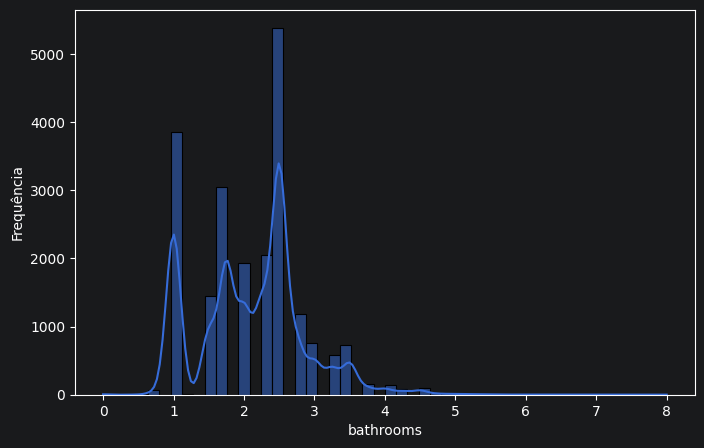

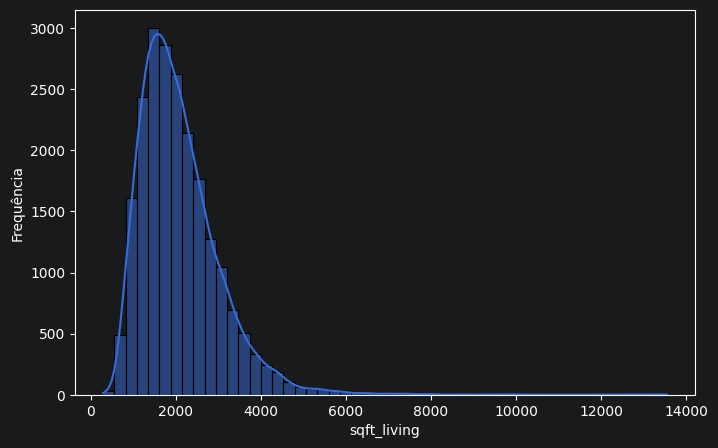

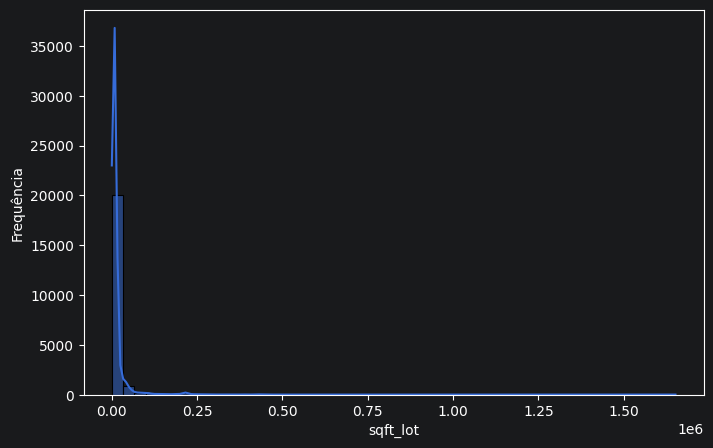

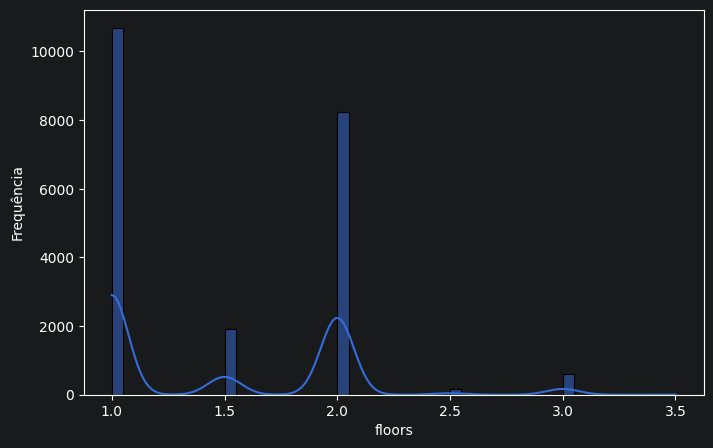

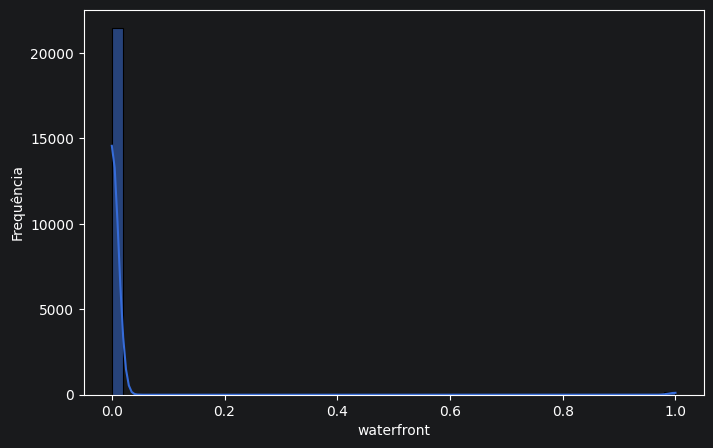

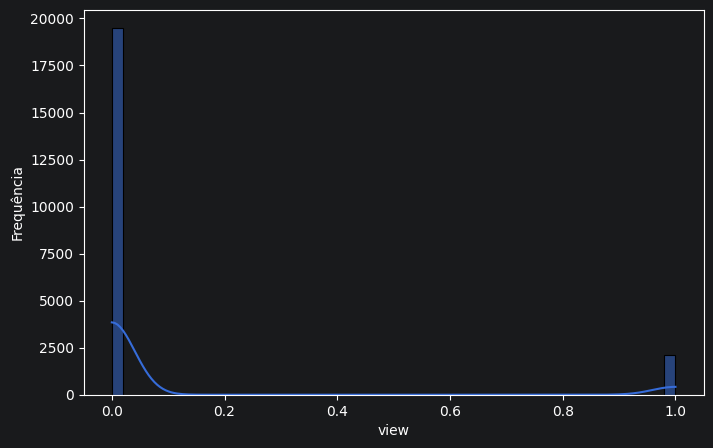

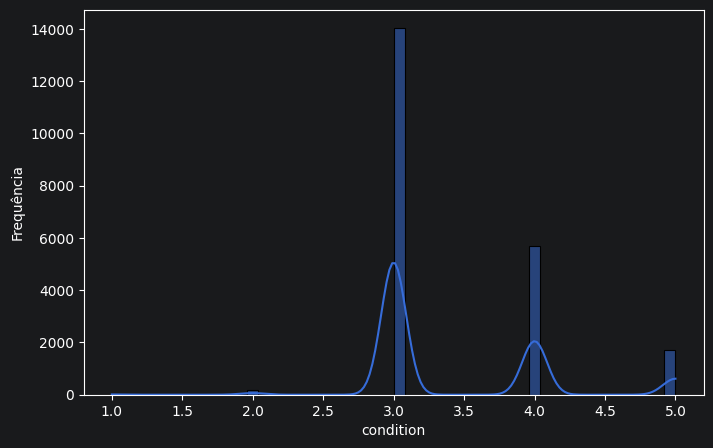

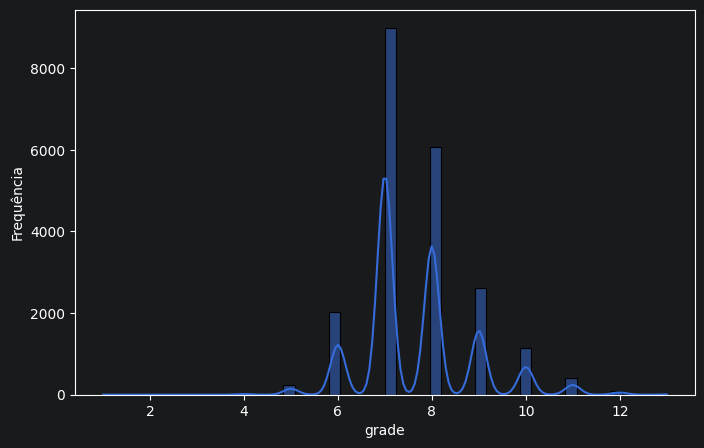

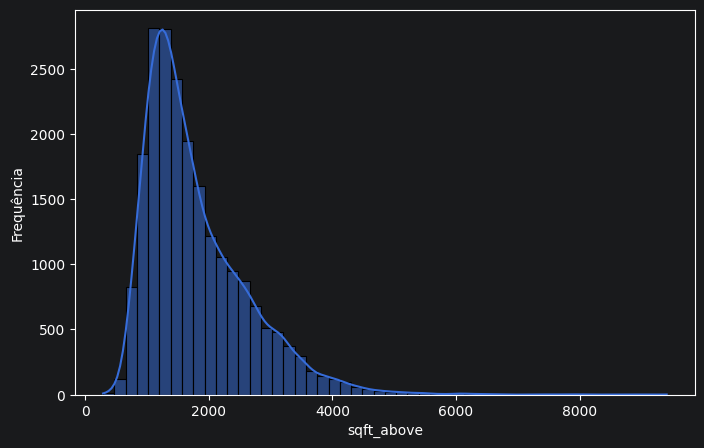

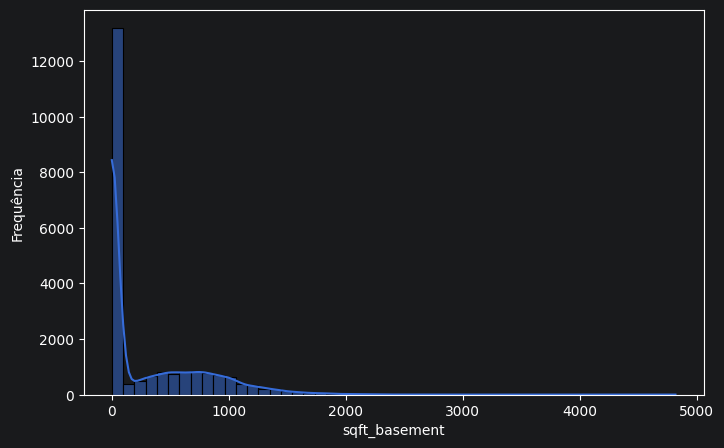

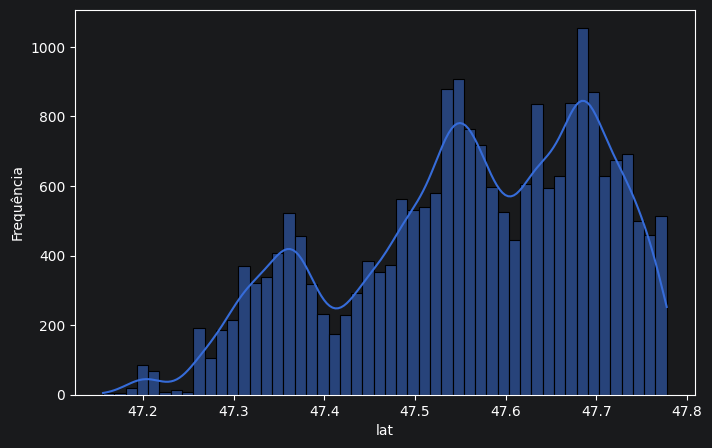

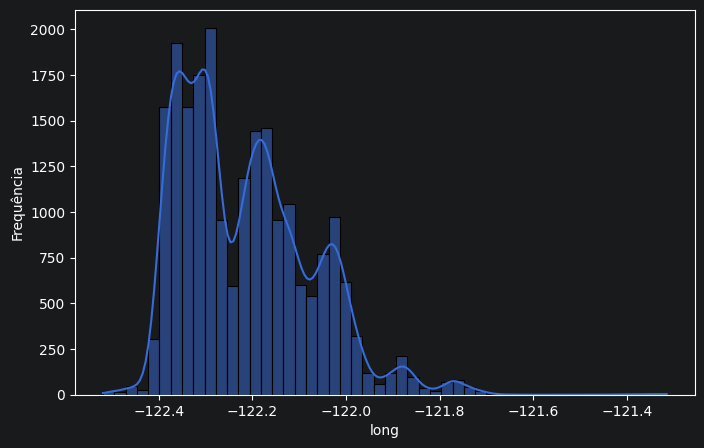

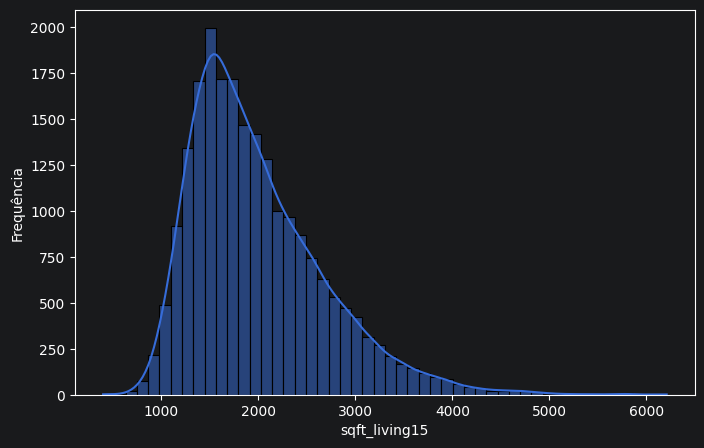

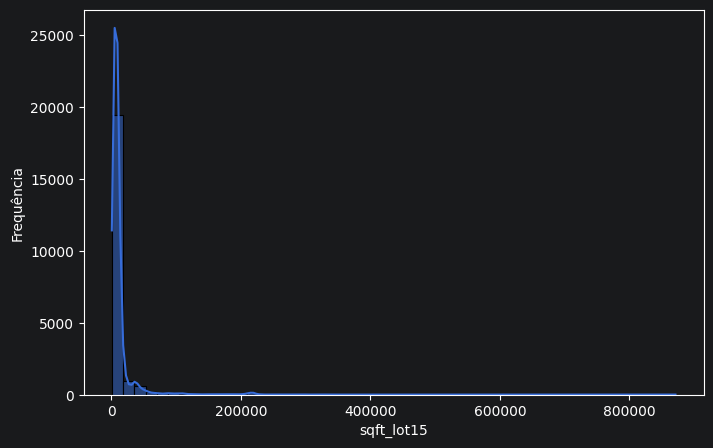

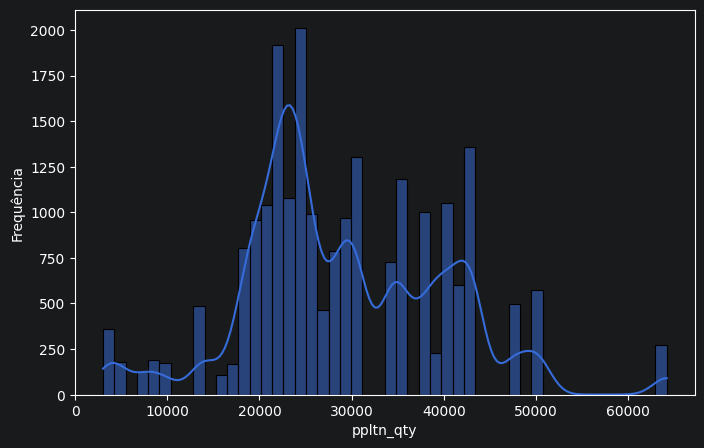

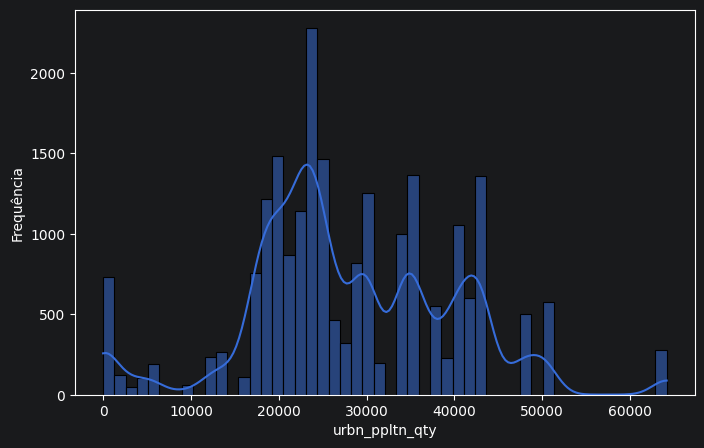

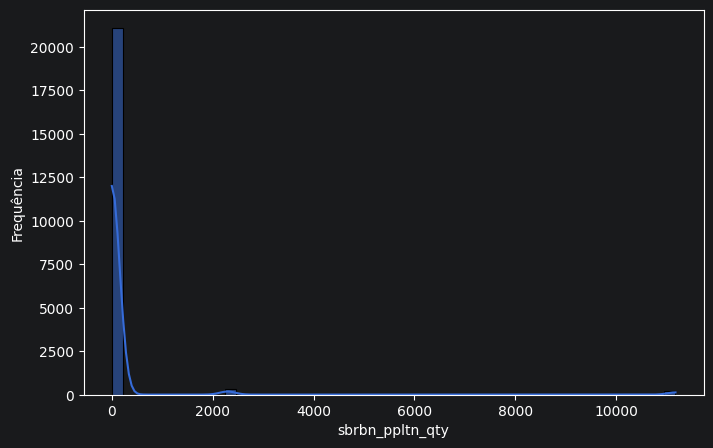

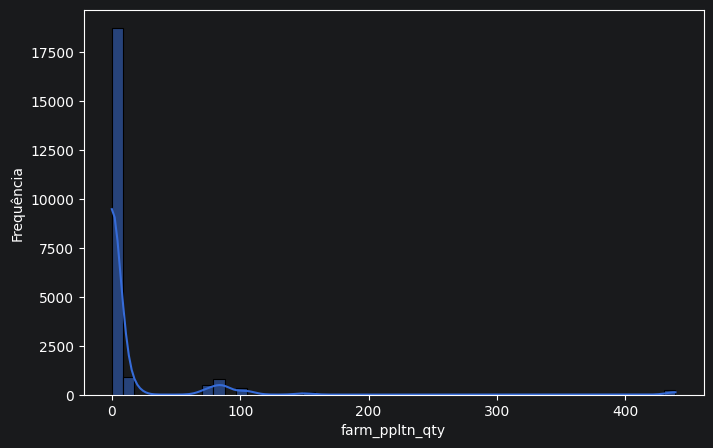

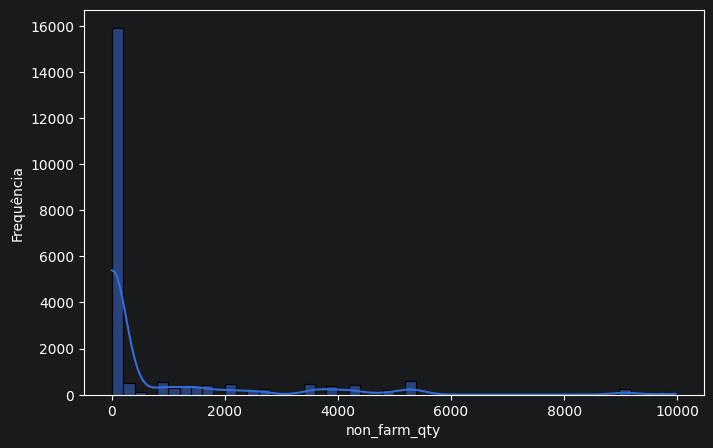

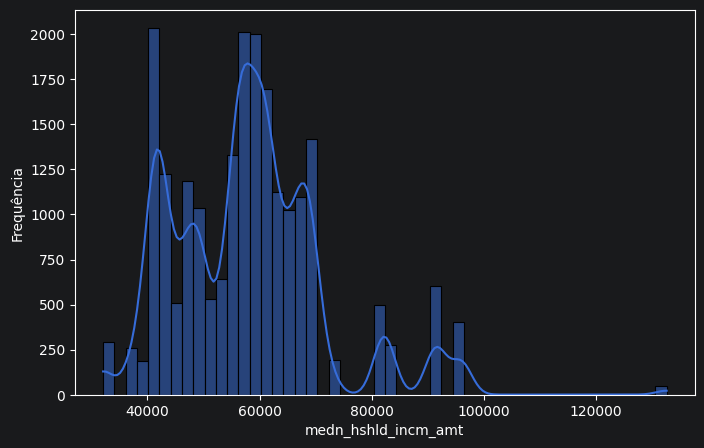

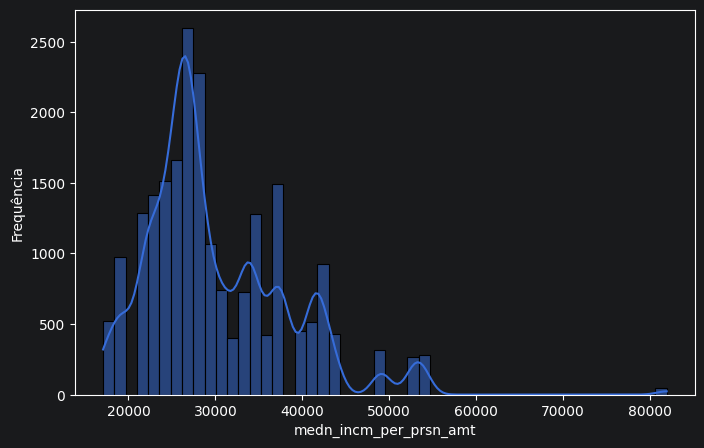

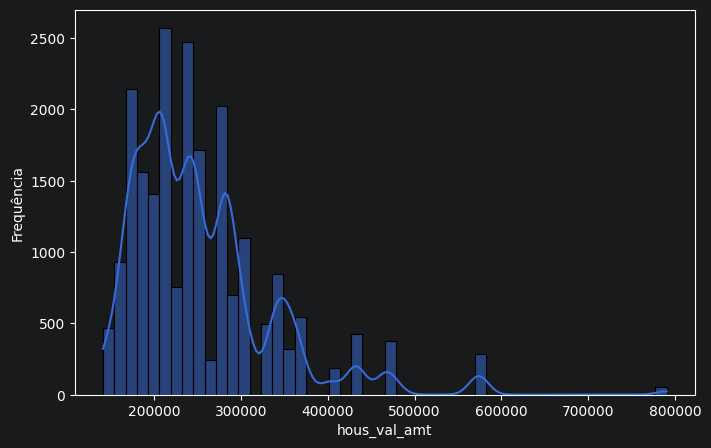

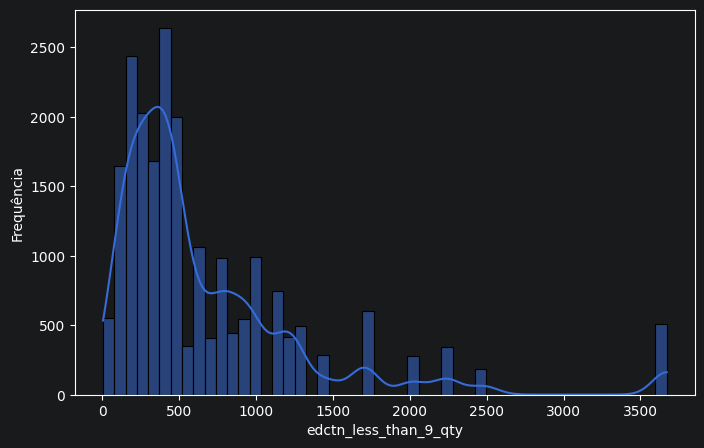

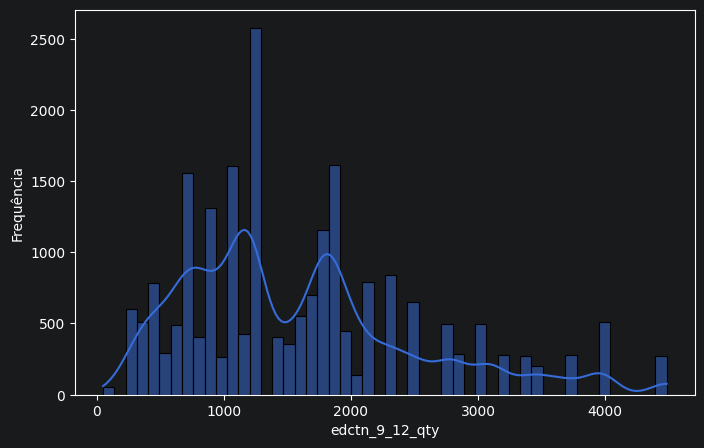

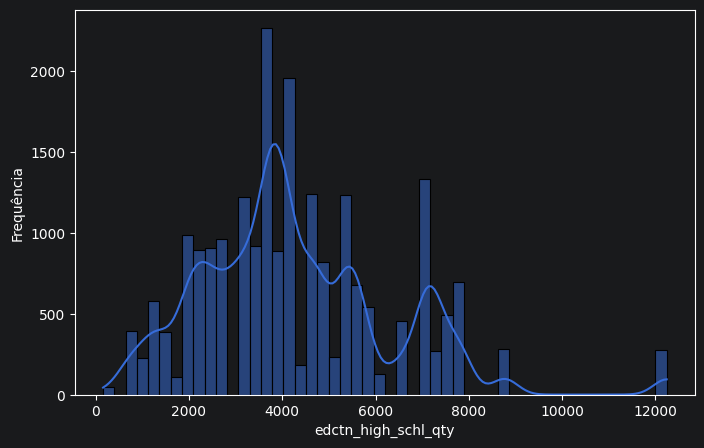

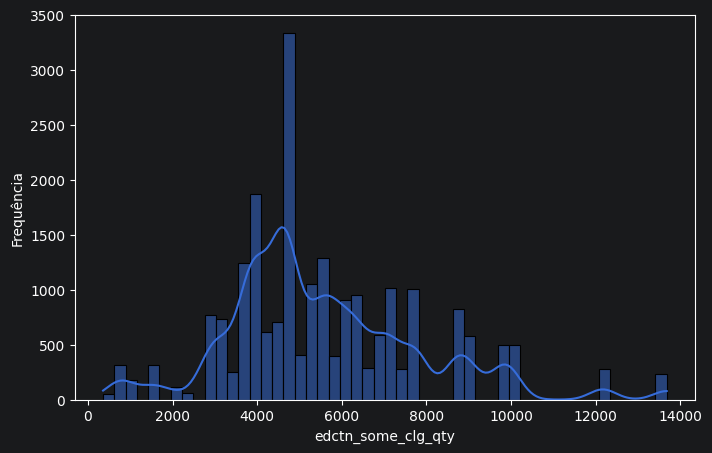

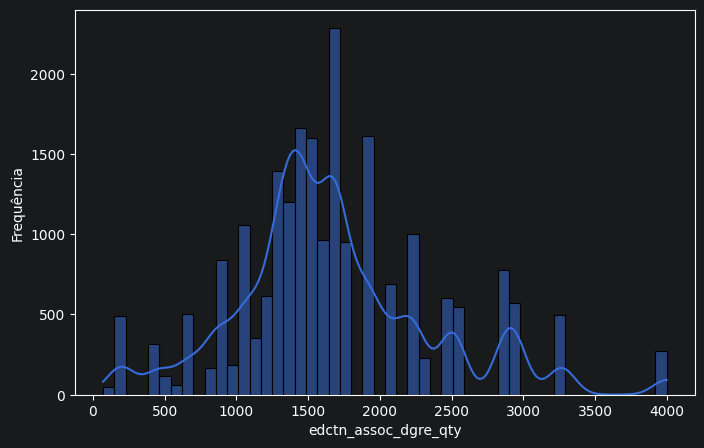

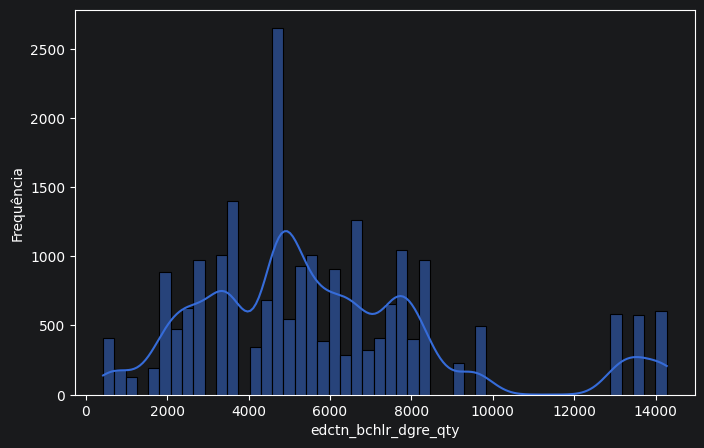

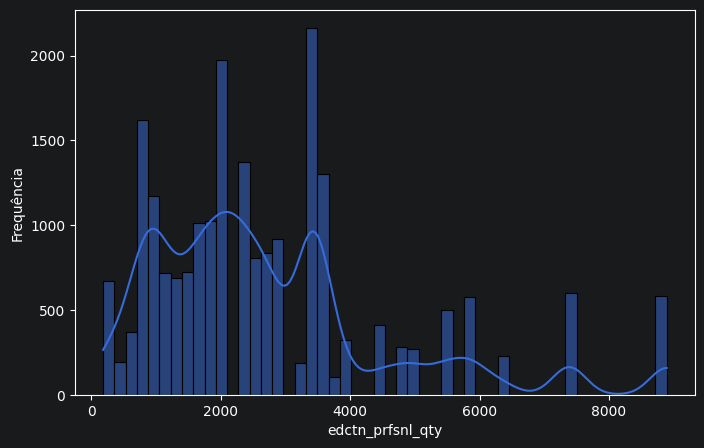

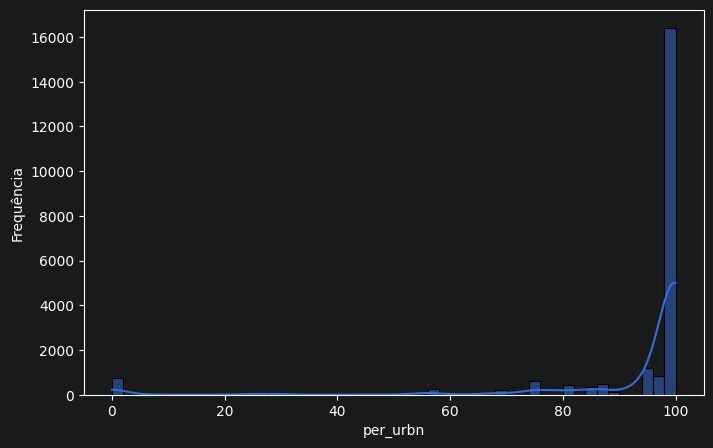

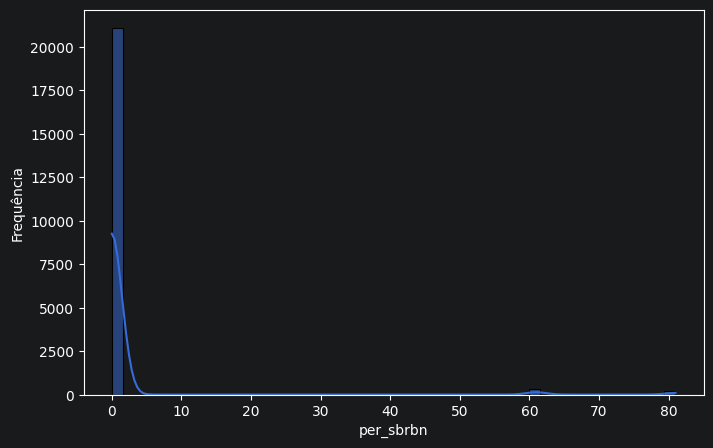

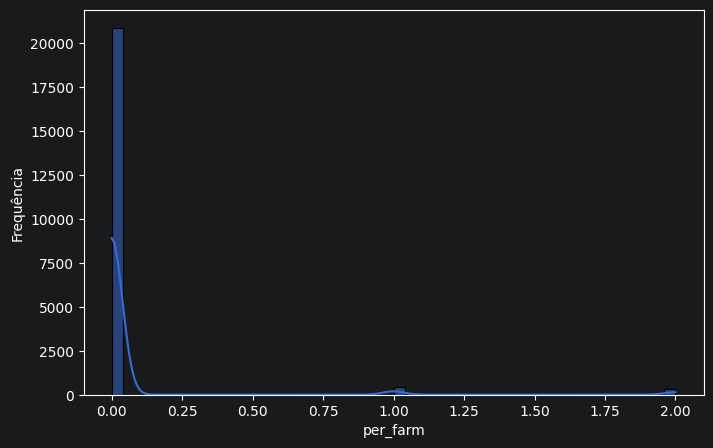

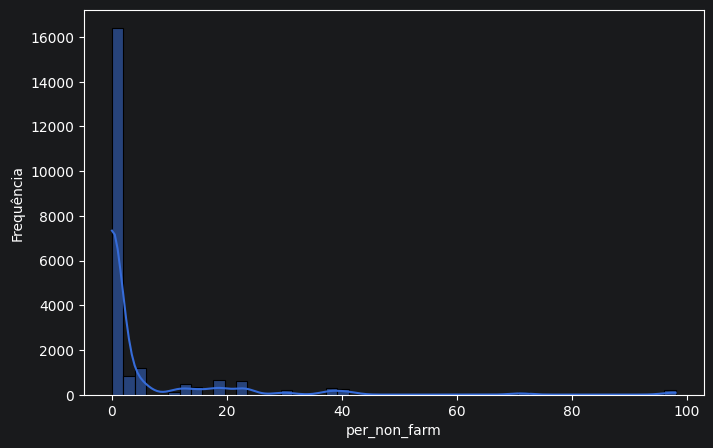

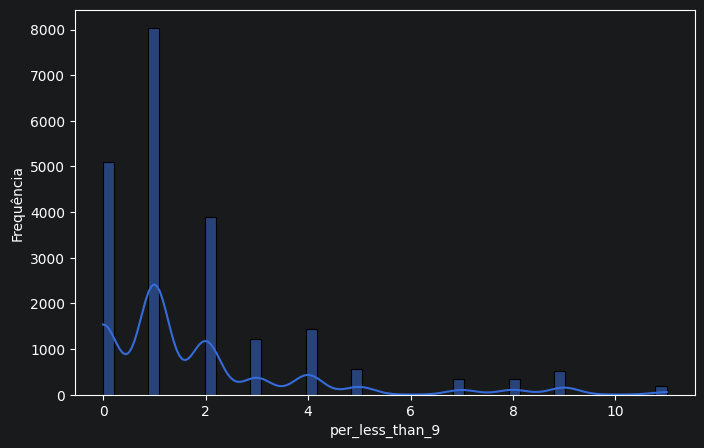

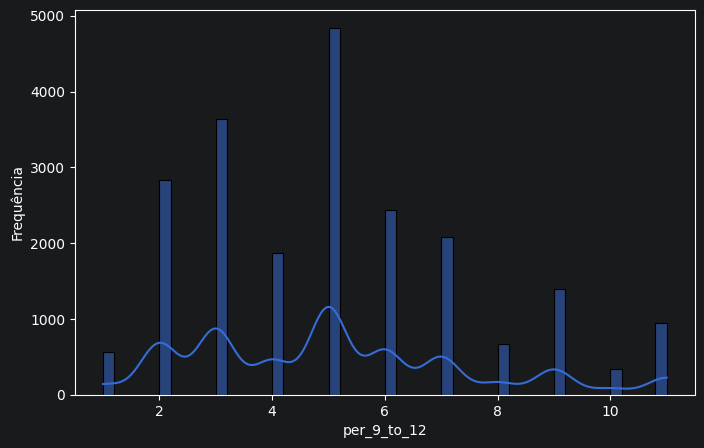

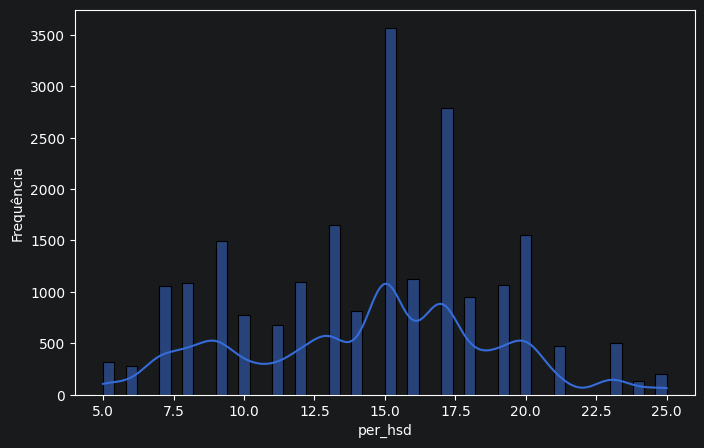

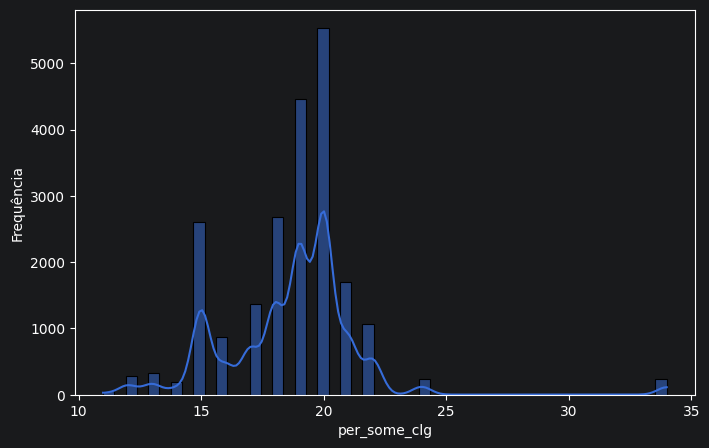

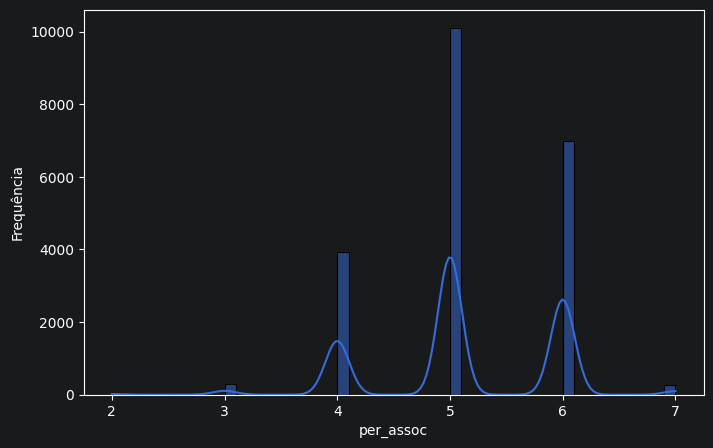

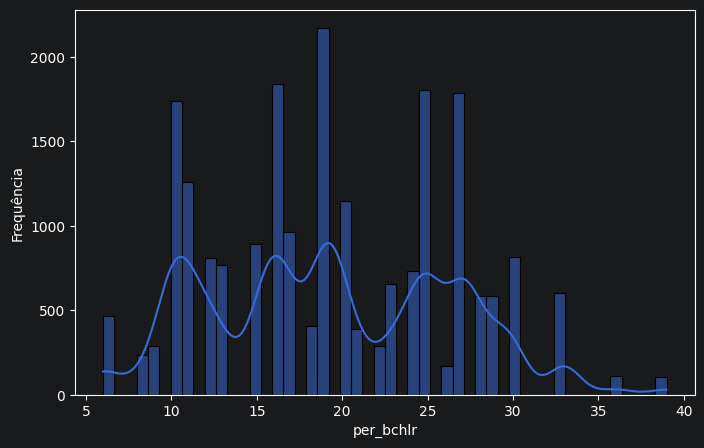

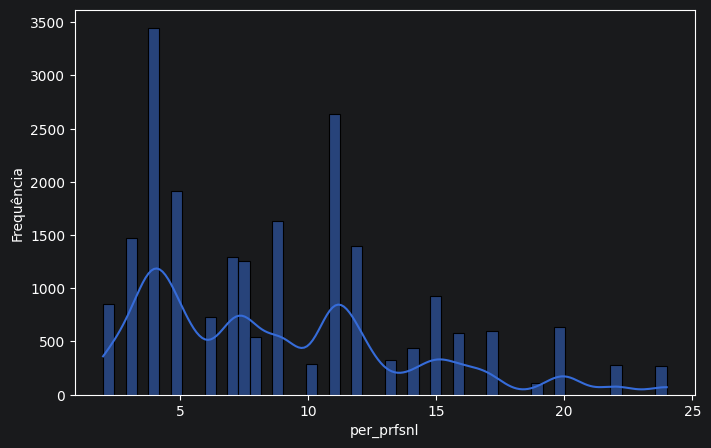

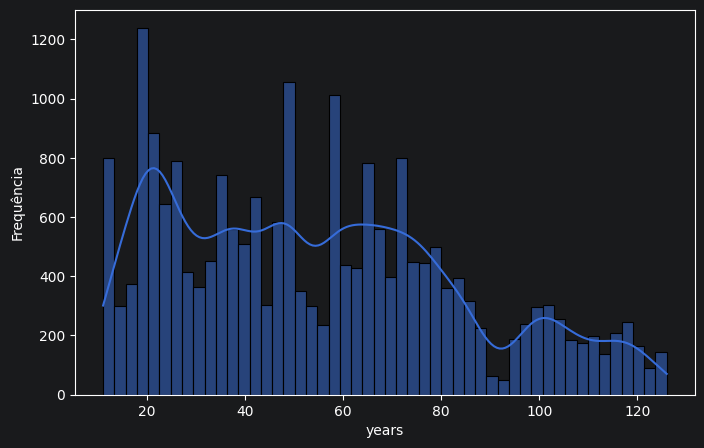

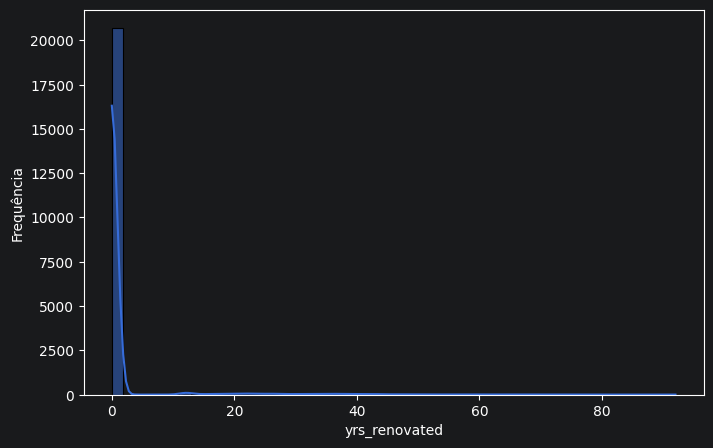

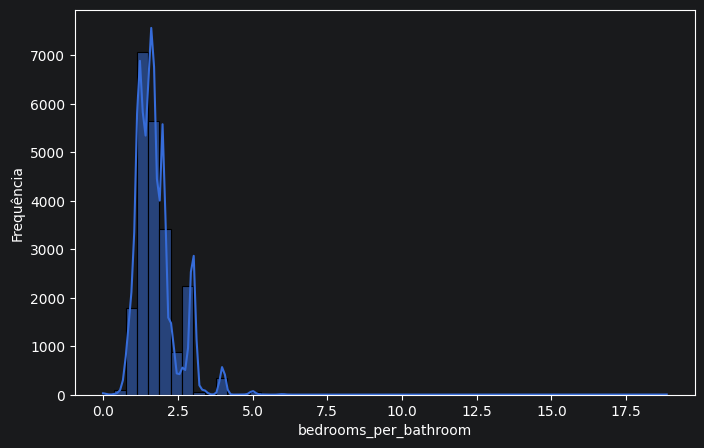

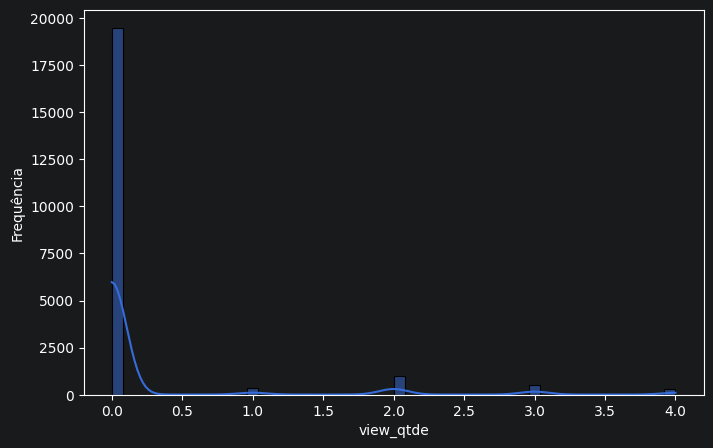

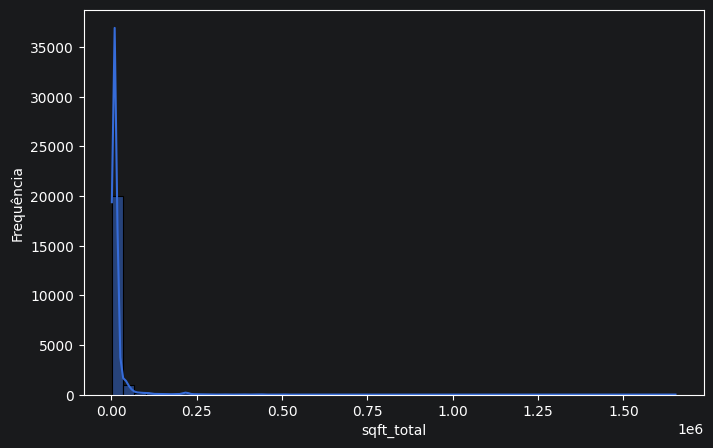

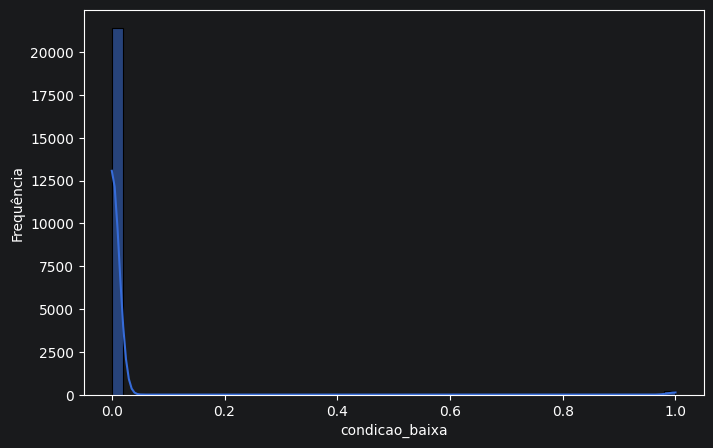

In [112]:
col_numeric = df.select_dtypes(include=np.number).columns

for col in col_numeric:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.savefig(f'imagens/{col}_hist.png')
    plt.show()

## Análise dos histogramas das variáveis numéricas

Os histogramas permitem observar a distribuição das variáveis numéricas do dataset e identificar padrões importantes, como concentração de valores, assimetrias e possíveis valores extremos.

De modo geral, algumas variáveis apresentam distribuição assimétrica à direita, principalmente `price`, `sqft_living`, `sqft_lot` e outras medidas relacionadas ao tamanho dos imóveis. Isso indica que a maior parte das casas está concentrada em faixas de valores menores ou intermediárias, enquanto uma quantidade menor de imóveis apresenta valores muito elevados.

No caso da variável `price`, a concentração maior ocorre em preços mais baixos e médios, enquanto poucos imóveis possuem preços muito altos. Esse comportamento sugere a presença de imóveis de luxo ou propriedades com características diferenciadas, que podem influenciar a média e o desempenho do modelo preditivo.

Variáveis como `bedrooms`, `bathrooms`, `floors` e `grade` apresentam valores mais discretos e concentrados em determinadas faixas, pois representam características estruturais dos imóveis. Já variáveis como área construída, área do terreno e informações demográficas possuem maior dispersão, indicando maior variabilidade entre as propriedades e suas regiões.

Essa análise inicial é importante para compreender o comportamento dos dados antes da modelagem, pois distribuições muito assimétricas e valores extremos podem afetar o treinamento do modelo e a interpretação das relações entre as variáveis.

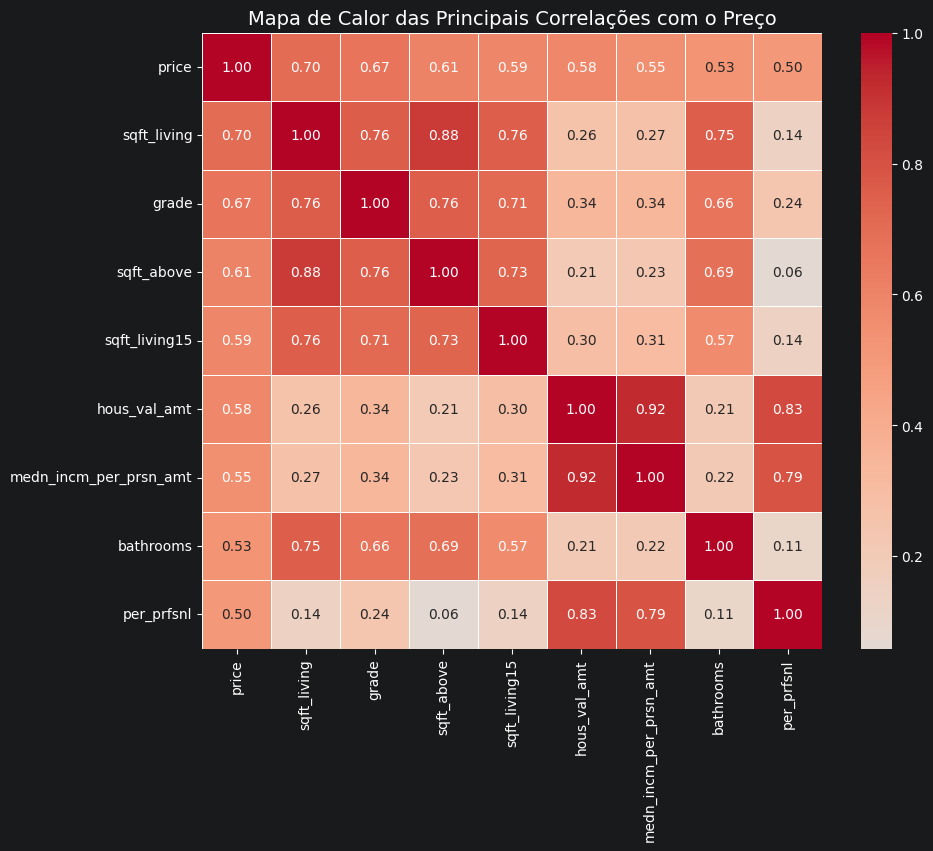

In [113]:
df_number = df.select_dtypes(include=np.number)

corr = df_number.corr()

top_features = corr["price"].abs().sort_values(ascending=False).head(9).index

corr_price = df_number[top_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_price,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Mapa de Calor das Principais Correlações com o Preço", fontsize=14)
plt.savefig("imagens/mapa_de_calor.png")
plt.show()

## Análise do mapa de calor das correlações

O mapa de calor apresenta a correlação linear entre as variáveis numéricas do conjunto de dados. Cada célula indica o grau de relação entre duas variáveis, com valores variando de -1 a 1. Valores próximos de 1 indicam correlação positiva forte, valores próximos de -1 indicam correlação negativa forte, e valores próximos de 0 indicam pouca ou nenhuma relação linear.

Nesta análise, a variável `price` é o principal foco, pois representa o valor dos imóveis. Observa-se que algumas variáveis possuem maior correlação com o preço, como `sqft_living`, `grade`, `sqft_above`, `sqft_living15` e `bathrooms`. Isso indica que imóveis com maior área construída, melhor classificação estrutural e maior número de banheiros tendem a apresentar preços mais elevados.

A variável `sqft_living` se destaca por apresentar uma das correlações mais fortes com `price`, mostrando que o tamanho da área habitável é um dos fatores mais relevantes para a valorização do imóvel. Além disso, `grade` também possui forte influência, pois está relacionada à qualidade geral da construção e do acabamento.

Também é possível observar correlações entre variáveis explicativas, como `sqft_living`, `sqft_above`, `bathrooms` e `sqft_living15`. Isso mostra que algumas características dos imóveis estão relacionadas entre si, o que pode influenciar a modelagem preditiva. Em modelos de regressão, esse comportamento deve ser observado com atenção, pois variáveis muito correlacionadas entre si podem causar redundância de informação.

De forma geral, o mapa de calor ajuda a identificar quais atributos possuem maior relação com o preço dos imóveis e quais variáveis podem ser mais relevantes para o treinamento do modelo de previsão. Essa etapa é importante para compreender melhor os dados, selecionar características úteis e interpretar os fatores que mais impactam o valor final das casas.

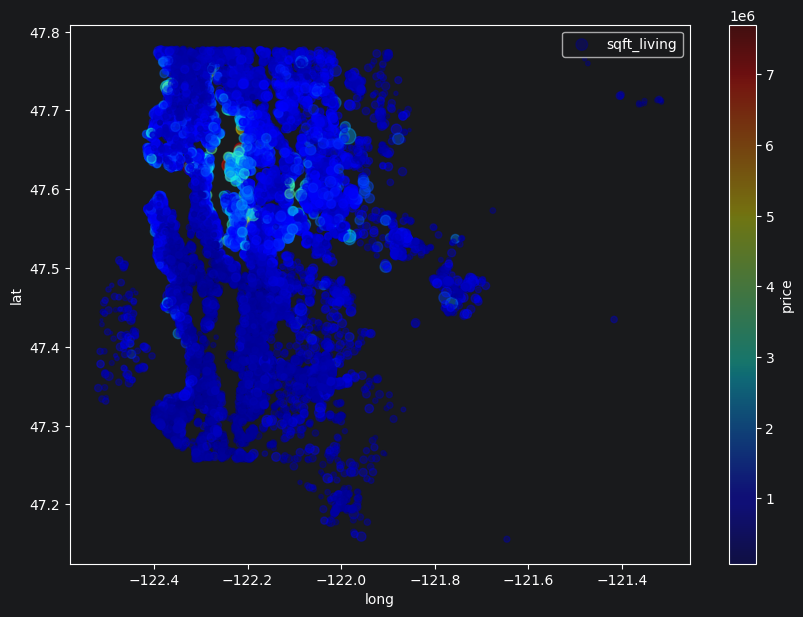

In [114]:
# Gráfico geográfico simples
# Nesta célula é gerado um gráfico de dispersão usando longitude e latitude. A cor representa o preço dos imóveis e o tamanho dos pontos está relacionado à área habitável.

df.plot(kind = "scatter", x = "long", y = "lat", alpha = 0.4, s = df["sqft_living"]/100, label = "sqft_living", figsize = (10,7), c = "price", cmap = plt.get_cmap("jet"), colorbar = True)
plt.savefig("imagens/mapa_de_lat_long.png")
plt.show()

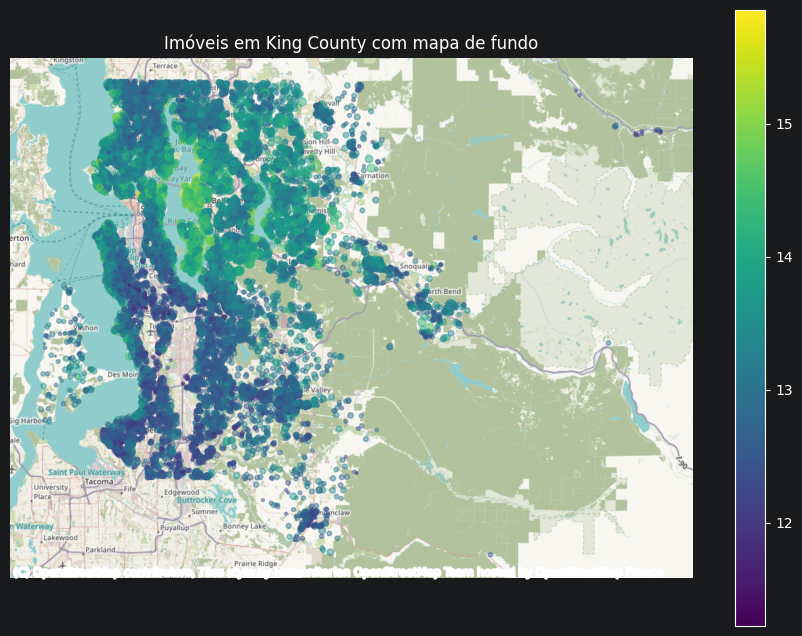

In [115]:
# Mapa com base geográfica
# Nesta célula os imóveis são convertidos em dados geográficos com 'GeoDataFrame' e exibidos sobre um mapa real. A cor representa o 'log_price' e o tamanho dos pontos considera a área habitável.


df["log_price"] = np.log1p(df["price"])

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["long"], df["lat"]),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

ax = gdf.plot(
    column="log_price",
    markersize=gdf["sqft_living"] / 200,
    alpha=0.45,
    cmap="viridis",
    legend=True,
    figsize=(11, 8)
)

cx.add_basemap(ax)

plt.title("Imóveis em King County com mapa de fundo")
plt.axis("off")
plt.savefig("imagens/mapa_de_kc.png")
plt.show()

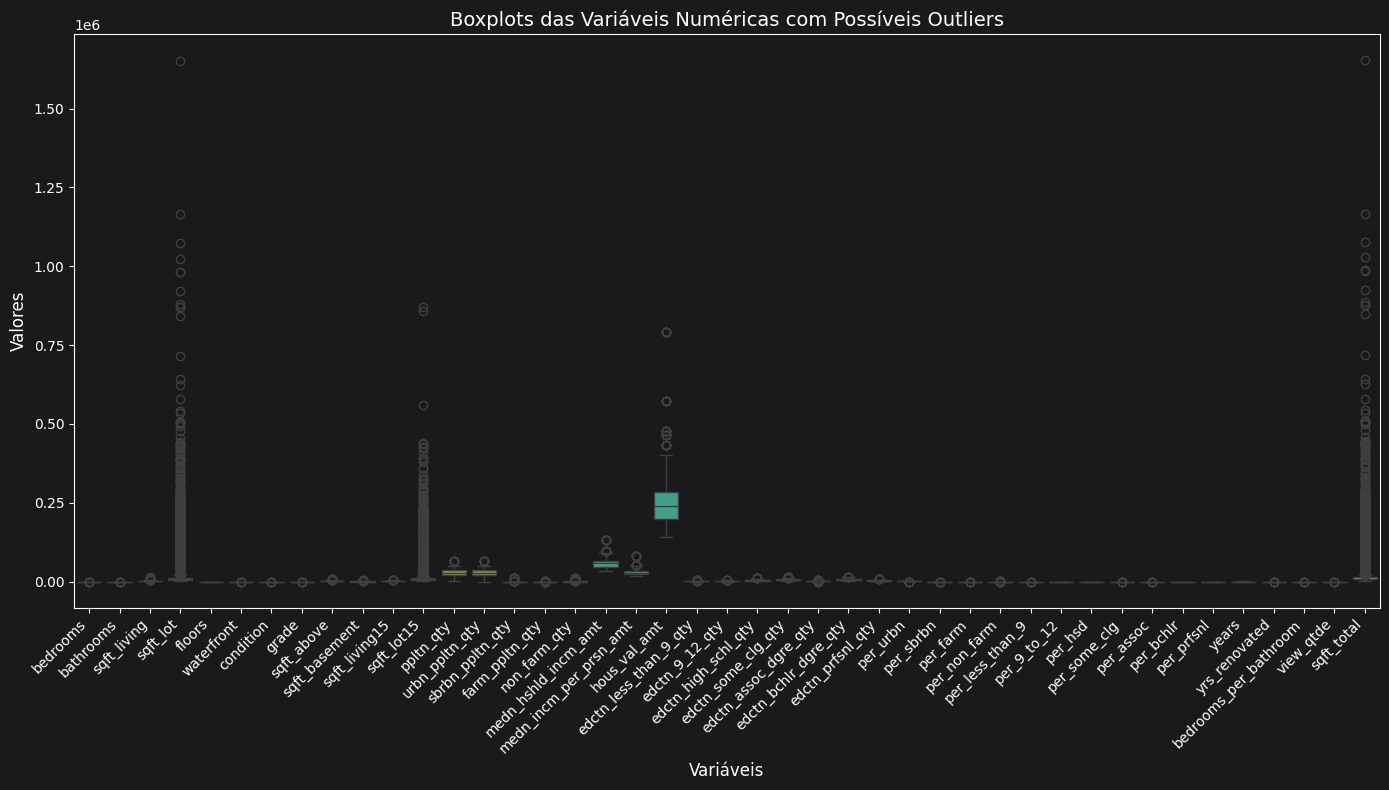

In [116]:
col_nao_tratar = [
    "price",
    "log_price",
    "lat",
    "long",
    "view",
    "condicao_baixa"
]

col_outliers = [
    col for col in col_numeric
    if col not in col_nao_tratar
]

plt.figure(figsize=(14, 8))

sns.boxplot(data=df[col_outliers])

plt.title("Boxplots das Variáveis Numéricas com Possíveis Outliers", fontsize=14)
plt.xlabel("Variáveis", fontsize=12)
plt.ylabel("Valores", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [117]:
resumo_outliers = []
limites_outliers = {}

for col in col_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
    percentual = (qtd_outliers / len(df)) * 100

    limites_outliers[col] = {
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior
    }

    resumo_outliers.append({
        "Variável": col,
        "Limite Inferior": limite_inferior,
        "Limite Superior": limite_superior,
        "Qtd Outliers": qtd_outliers,
        "% Outliers": percentual
    })

resumo_outliers = pd.DataFrame(resumo_outliers)

resumo_outliers.sort_values(by="Qtd Outliers", ascending=False).head(15)

,Variável,Limite Inferior,Limite Superior,Qtd Outliers,% Outliers
30,per_non_farm,0.0,0.0,5326,24.642576
27,per_urbn,97.5,101.5,5201,24.064221
16,non_farm_qty,-375.0,625.0,5101,23.601536
31,per_less_than_9,-0.5,3.5,3364,15.564706
15,farm_ppltn_qty,0.0,0.0,2884,13.343821
3,sqft_lot,-3432.0,19160.0,2425,11.220099
42,sqft_total,-1912.5,21947.5,2419,11.192338
11,sqft_lot15,-2374.5,17557.5,2194,10.151298
41,view_qtde,0.0,0.0,2124,9.827419
20,edctn_less_than_9_qty,-581.5,1686.5,1915,8.860408


In [118]:
# Cria uma cópia do dataset para preservar os dados originais
df_tratado = df.copy()

# Aplica o metodo de clipping:
# valores abaixo do limite inferior recebem o limite inferior;
# valores acima do limite superior recebem o limite superior.
for col in col_outliers:
    limite_inferior = limites_outliers[col]["limite_inferior"]
    limite_superior = limites_outliers[col]["limite_superior"]

    df_tratado[col] = df_tratado[col].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

df_tratado.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_assoc,per_bchlr,per_prfsnl,years,yrs_renovated,bedrooms_per_bathroom,view_qtde,sqft_total,condicao_baixa,log_price
0,221900.0,3.0,1.00,1180.0,5650,1.0,0,0,3.0,7.0,...,5.0,12.0,4.0,71,0,3.000000,0,6830.0,0,12.309987
1,538000.0,3.0,2.25,2570.0,7242,2.0,0,0,3.0,7.0,...,5.0,20.0,12.0,75,0,1.333333,0,9812.0,0,13.195616
2,180000.0,2.0,1.00,770.0,10000,1.0,0,0,3.0,6.0,...,6.0,19.0,9.0,93,0,2.000000,0,10770.0,0,12.100718
3,604000.0,4.0,3.00,1960.0,5000,1.0,0,0,5.0,7.0,...,7.0,25.0,12.0,61,0,1.333333,0,6960.0,0,13.311331
4,510000.0,3.0,2.00,1680.0,8080,1.0,0,0,3.0,8.0,...,5.0,19.0,7.5,39,0,1.500000,0,9760.0,0,13.142168


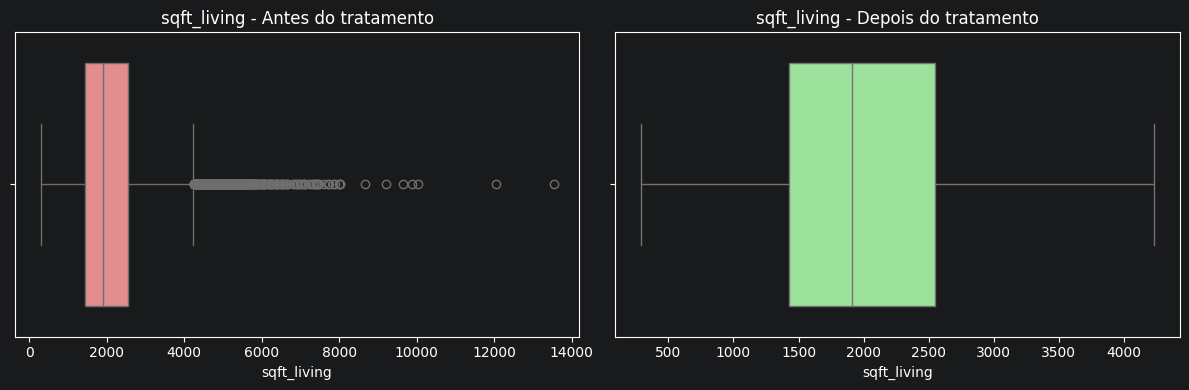

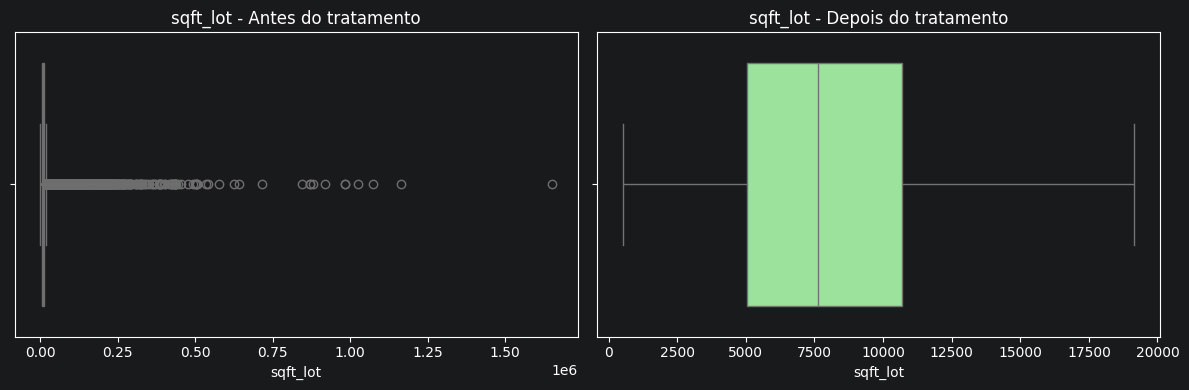

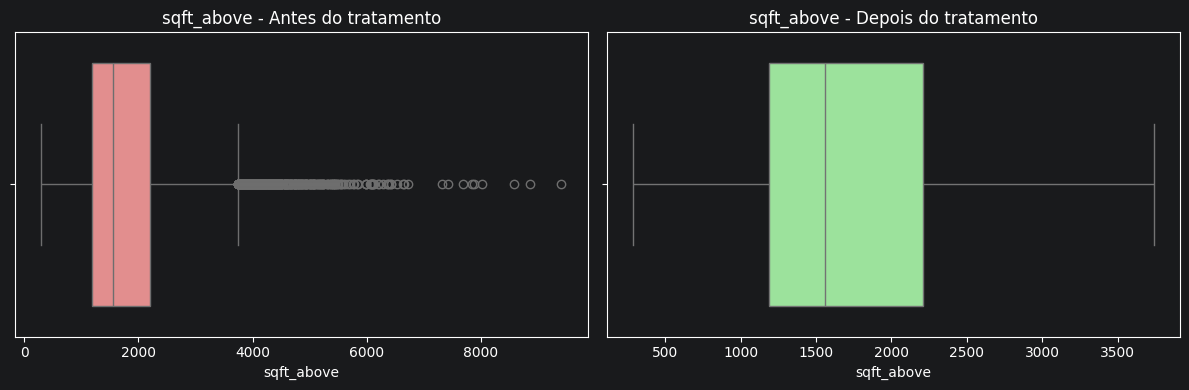

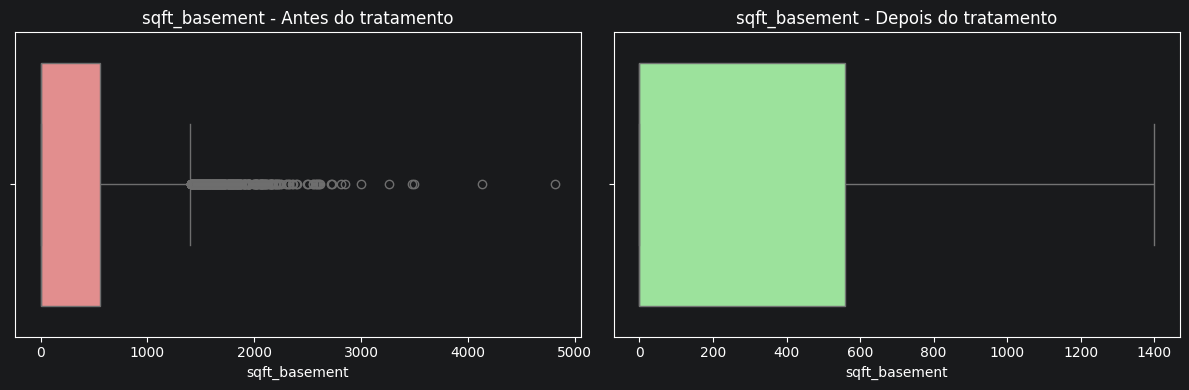

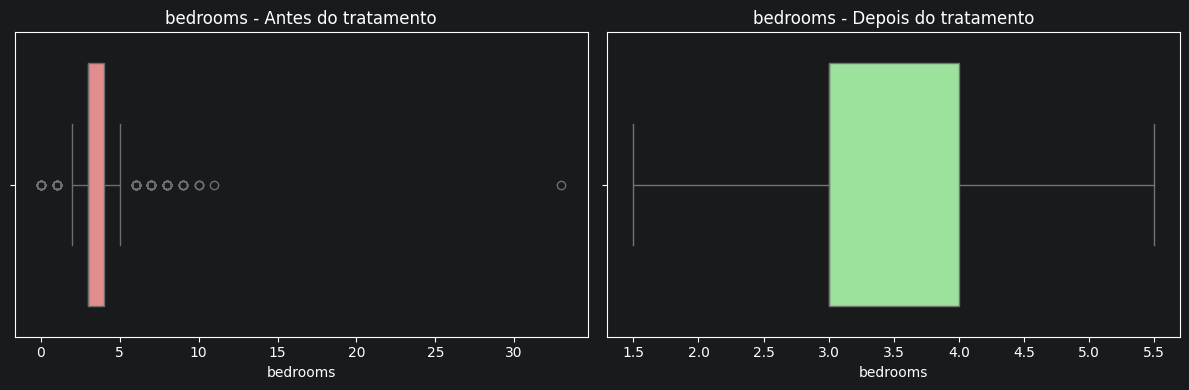

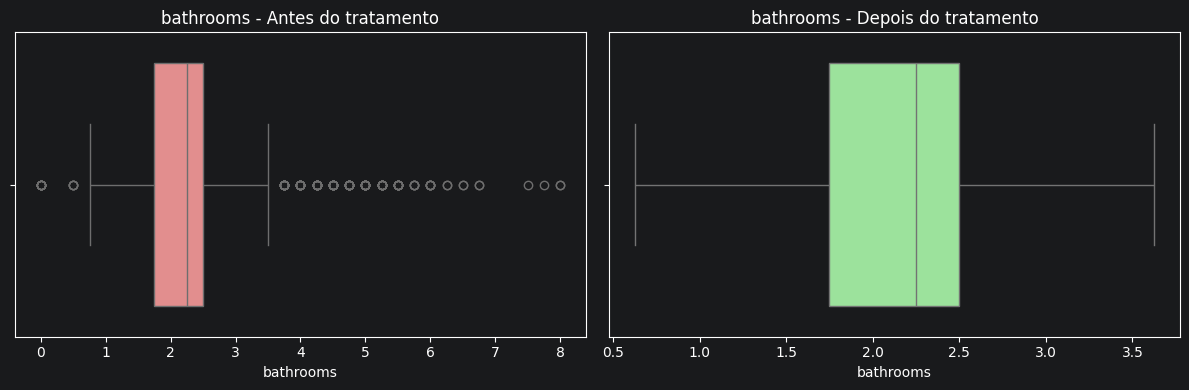

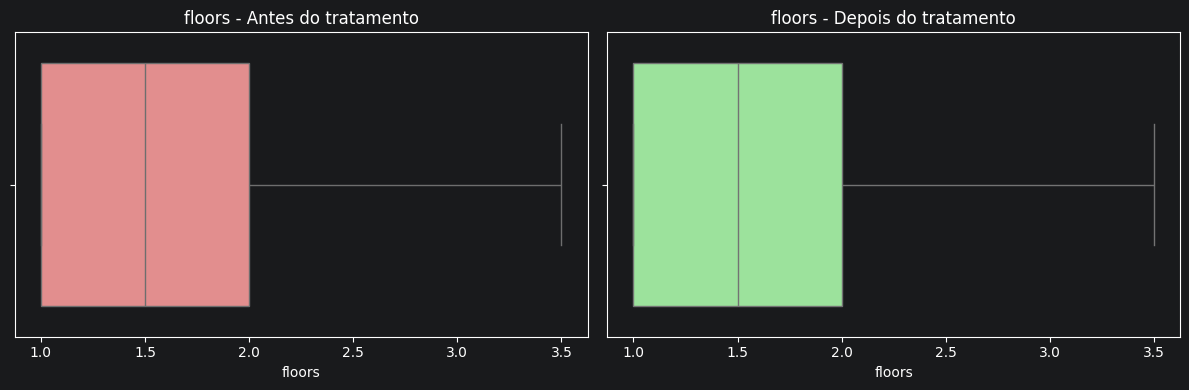

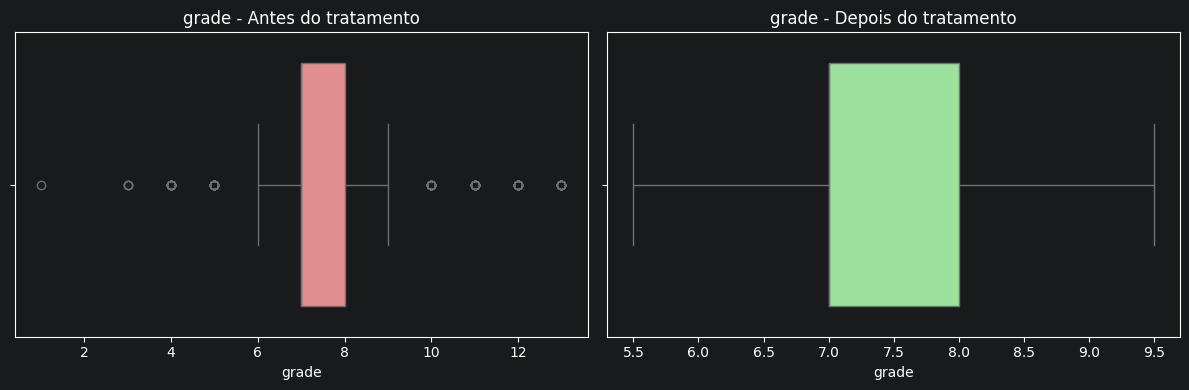

In [119]:
col_comparacao = [
    "sqft_living",
    "sqft_lot",
    "sqft_above",
    "sqft_basement",
    "bedrooms",
    "bathrooms",
    "floors",
    "grade"
]

col_comparacao = [col for col in col_comparacao if col in df.columns]

for col in col_comparacao:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color="lightcoral")
    plt.title(f"{col} - Antes do tratamento")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_tratado[col], color="lightgreen")
    plt.title(f"{col} - Depois do tratamento")

    plt.tight_layout()
    plt.savefig(rf"imagens/{col}_antes_e_depois.png")
    plt.show()

## Tratamento de outliers

Após a análise inicial dos dados, foi realizada a verificação de outliers nas variáveis numéricas. Outliers são valores muito distantes da maior parte dos dados e podem influenciar negativamente alguns modelos de aprendizado de máquina, principalmente modelos sensíveis à escala e à distribuição das variáveis.

Para identificar esses valores extremos, foi utilizado o método do intervalo interquartil, conhecido como IQR. Esse método calcula o primeiro quartil, o terceiro quartil e a diferença entre eles. A partir disso, são definidos limites inferior e superior para cada variável. Valores abaixo do limite inferior ou acima do limite superior são considerados possíveis outliers.

No contexto deste dataset, é importante destacar que alguns outliers podem representar imóveis reais com características diferenciadas, como casas de luxo, terrenos muito grandes ou imóveis com áreas construídas acima da média. Por esse motivo, os outliers não foram simplesmente removidos. Em vez disso, foi aplicado o método de clipping, que limita os valores extremos aos limites calculados pelo IQR.

A variável `price` não foi tratada diretamente nessa etapa, pois representa a variável alvo do problema. Alterar seus valores poderia distorcer a previsão final do modelo. Além disso, variáveis como `lat` e `long` também foram mantidas sem alteração, pois representam localização geográfica e não devem ser interpretadas como outliers da mesma forma que variáveis físicas ou financeiras.

Com esse tratamento, o dataset preserva os registros originais, mas reduz o impacto de valores extremos nas variáveis explicativas. Isso contribui para uma modelagem mais estável e evita que poucos valores muito altos ou muito baixos tenham influência excessiva durante o treinamento do modelo.

# **Treinamento do Modelo**

In [120]:
# 1. Carregando os dados já pré-processados

X = df_tratado.drop(columns=["price", "log_price"], errors="ignore")
y = df_tratado["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Teste : {X_test.shape[0]} amostras")

Treino: 15129 amostras, 47 features
Teste : 6484 amostras


In [121]:
# 2. Modelo base MLP (sem ajuste)
modelo_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42,
        early_stopping=True
    ))
])
modelo_mlp.fit(X_train, y_train)

y_pred_base = modelo_mlp.predict(X_test)
print("\n--- Modelo Base (MLP padrão) ---")
print(f"MAE : US$ {mean_absolute_error(y_test, y_pred_base):,.2f}")
print(f"RMSE: US$ {np.sqrt(mean_squared_error(y_test, y_pred_base)):,.2f}")
print(f"R²  : {r2_score(y_test, y_pred_base):.4f}")


--- Modelo Base (MLP padrão) ---
MAE : US$ 98,992.58
RMSE: US$ 185,790.63
R²  : 0.7609


In [122]:
# 3. Ajuste de hiperparâmetros com GridSearchCV
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42,
        early_stopping=True
    ))
])

param_grid = {
    "mlp__hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
    "mlp__learning_rate_init": [0.001, 0.01],
    "mlp__alpha": [0.0001, 0.001],
}

grid = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nMelhores parâmetros:", grid.best_params_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits

Melhores parâmetros: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.01}


In [123]:
# 4. Avaliação do modelo otimizado
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n--- Modelo MLP Otimizado ---")
print(f"MAE : US$ {mae:,.2f}")
print(f"RMSE: US$ {rmse:,.2f}")
print(f"R²  : {r2:.4f}")


--- Modelo MLP Otimizado ---
MAE : US$ 83,826.57
RMSE: US$ 159,832.61
R²  : 0.8230


In [124]:
# 5. Validação cruzada
scores = cross_val_score(best_model, X_train, y_train,
                         cv=5, scoring="neg_mean_absolute_error")
print(f"\nMAE médio (cross-val 5 folds): US$ {-scores.mean():,.2f} (+/- {scores.std():,.2f})")


MAE médio (cross-val 5 folds): US$ 83,773.92 (+/- 4,465.36)


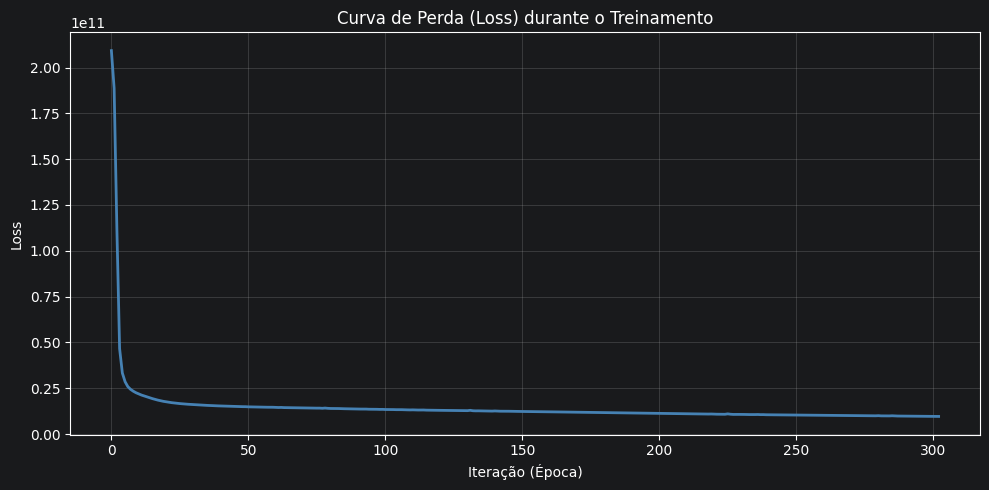

In [125]:
# 6. Curva de perda (loss)

mlp_model = best_model.named_steps["mlp"]

plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, color="steelblue", linewidth=2)
plt.title("Curva de Perda (Loss) durante o Treinamento")
plt.xlabel("Iteração (Época)")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("imagens/mlp_loss_curve.png")
plt.show()

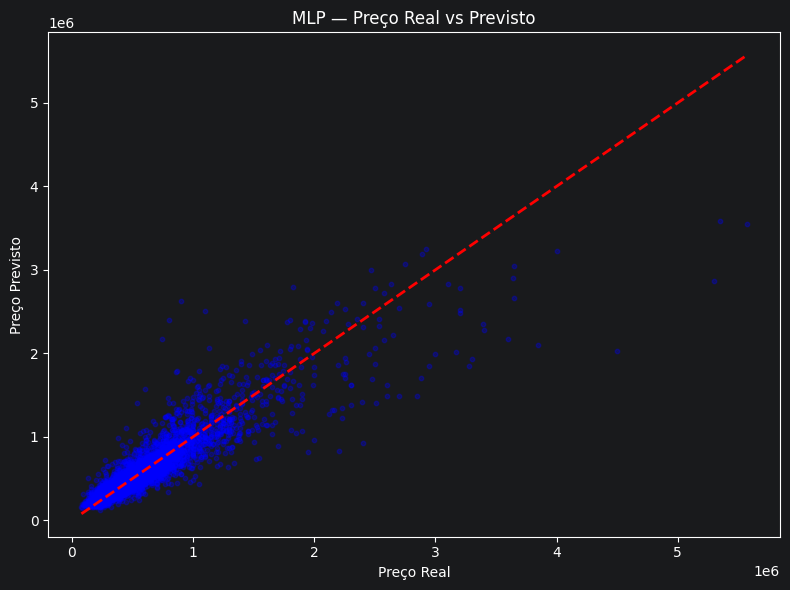

In [126]:
# 7. Gráfico Real vs Previsto
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color="blue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title("MLP — Preço Real vs Previsto")
plt.tight_layout()
plt.savefig("imagens/mlp_real_vs_previsto.png")
plt.show()

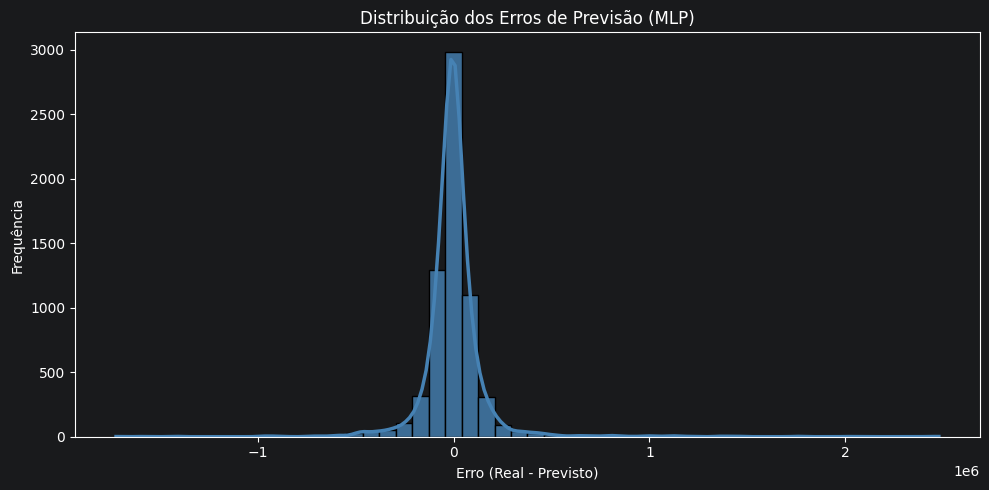

In [127]:
# 8. Distribuição dos erros
erros = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(erros, kde=True, bins=50, color="steelblue", alpha=0.8, line_kws={"color":"red", "linewidth": 2.5})
plt.title("Distribuição dos Erros de Previsão (MLP)")
plt.xlabel("Erro (Real - Previsto)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig("imagens/mlp_distribuicao_erros.png")
plt.show()

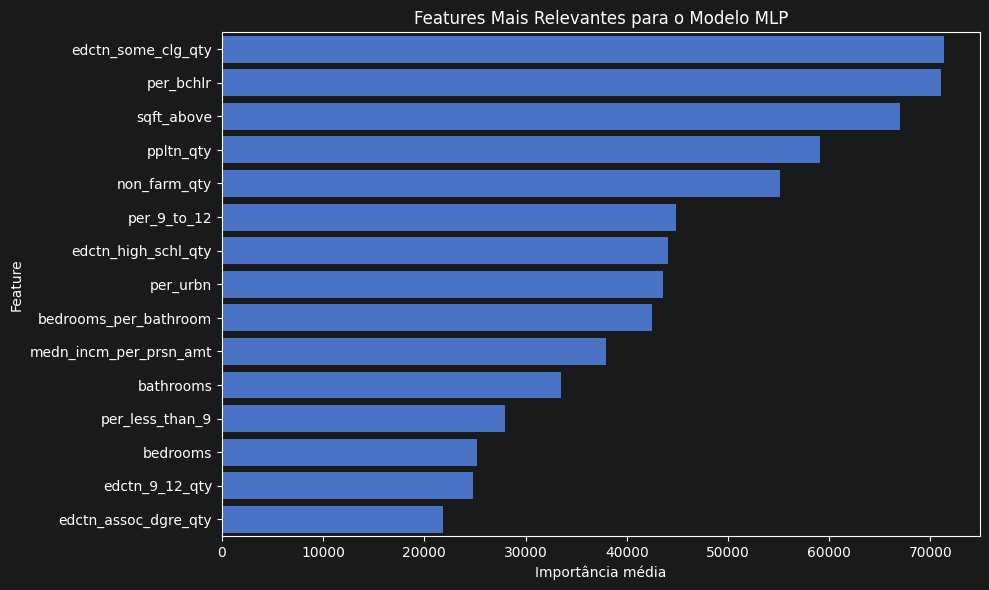

In [128]:
# 9. Atributos mais importantes

resultado_importancia = permutation_importance(best_model, X_test, y_test, scoring="neg_mean_absolute_error", n_repeats=10, random_state=42, n_jobs=-1)

importancia_features = pd.DataFrame({"Feature": X_test.columns, "Importancia": resultado_importancia.importances_mean, "Desvio": resultado_importancia.importances_std})

importancia_features = importancia_features.sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancia_features.head(15),
    x="Importancia",
    y="Feature"
)

plt.title("Features Mais Relevantes para o Modelo MLP")
plt.xlabel("Importância média")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("imagens/mlp_features_relevantes.png")
plt.show()

## Análise das features mais relevantes

O gráfico apresenta as variáveis mais relevantes para o modelo MLP, utilizando a técnica de **Permutation Importance**. Essa técnica mede a importância de cada variável ao embaralhar seus valores e observar o quanto o desempenho do modelo é prejudicado. Quanto maior a queda de desempenho após o embaralhamento, maior é a importância daquela feature para a previsão.

Observa-se que as variáveis mais relevantes foram `edctn_some_clg_qty`, `per_bchlr`, `sqft_above`, `ppltn_qty` e `non_farm_qty`. Isso indica que o modelo não considerou apenas características físicas do imóvel, mas também informações demográficas e socioeconômicas da região.

A variável `sqft_above` aparece entre as principais features físicas, mostrando que a área construída acima do nível do solo tem forte influência na previsão do preço. Esse resultado é coerente, pois imóveis com maior área construída tendem a apresentar valores mais elevados.

As variáveis demográficas, como `ppltn_qty`, `per_bchlr`, `edctn_some_clg_qty`, `edctn_high_schl_qty`, `per_urbn` e `medn_incm_per_prsn_amt`, também se destacam. Isso mostra que características da região, como população, nível educacional, urbanização e renda mediana por pessoa, ajudam o modelo a compreender diferenças de valorização entre localidades.

Além disso, variáveis estruturais como `bathrooms`, `bedrooms` e `bedrooms_per_bathroom` também aparecem entre as mais importantes. Isso indica que a quantidade de quartos, banheiros e a proporção entre eles contribuem para representar o conforto e o padrão do imóvel.

De forma geral, a análise mostra que o preço dos imóveis é influenciado por uma combinação de fatores físicos e regionais. Enquanto atributos como área construída, quartos e banheiros descrevem as características internas da casa, as variáveis demográficas ajudam a representar o contexto da vizinhança, tornando a previsão mais completa e realista.

In [129]:
# 10. Salvando o modelo

joblib.dump(best_model, "modelo_mlp.pkl")
print("\nModelo salvo em 'modelo_mlp.pkl'")


Modelo salvo em 'modelo_mlp.pkl'


# **Previsão com dataset futuro**

## Mesmas transformações feitas no dataset de treino

In [130]:
#Cópia do dataset futuro
df_future_pred = df_future.copy()

# Idade do imóvel
df_future_pred["years"] = 2026 - df_future_pred["yr_built"]
df_future_pred.drop("yr_built", axis=1, inplace=True)

# Tempo desde a última reforma
df_future_pred["yrs_renovated"] = df_future_pred["yr_renovated"].apply(
    lambda x: 0 if x == 0 else 2026 - x
)
df_future_pred.drop("yr_renovated", axis=1, inplace=True)

# Quartos por banheiro
df_future_pred["bedrooms_per_bathroom"] = df_future_pred["bedrooms"] / df_future_pred["bathrooms"].replace(0, np.nan)
df_future_pred['bedrooms_per_bathroom'] = df_future_pred['bedrooms_per_bathroom'].replace(np.nan, 0)


# Quantidade original de view
df_future_pred["view_qtde"] = df_future_pred["view"]

# View binária
df_future_pred["view"] = df_future_pred["view"].apply(lambda x: 0 if x == 0 else 1)

# Área total
df_future_pred["sqft_total"] = df_future_pred["sqft_living"] + df_future_pred["sqft_lot"]

# Condição baixa
df_future_pred["condicao_baixa"] = df_future_pred.apply(lambda row: 1 if row["condition"] <= 2 else 0, axis=1)

# Remove zipcode se ele também foi removido do treino
df_future_pred.drop(columns=["zipcode"], inplace=True, errors="ignore")


## Previsão

In [131]:
#Previsão

y_future_pred = best_model.predict(df_future_pred)

# Adiciona a previsão no dataframe original futuro
resultado_future = df_future.copy()
resultado_future["preco_previsto"] = y_future_pred

resultado_future.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,preco_previsto
0,4,1.00,1680,5043,1.5,0,0,4,6,1680,...,0.0,0.0,9.0,9.0,17.0,15.0,4.0,11.0,6.0,787642.190155
1,3,2.50,2220,6380,1.5,0,0,4,8,1660,...,0.0,0.0,0.0,2.0,8.0,15.0,4.0,30.0,20.0,745545.011654
2,3,2.25,1630,10962,1.0,0,0,4,8,1100,...,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5,296961.071102
3,5,2.50,1710,9720,2.0,0,0,4,8,1710,...,0.0,0.0,2.0,3.0,10.0,17.0,4.0,26.0,16.0,715722.182116
4,2,1.00,850,6370,1.0,0,0,3,6,850,...,0.0,0.0,4.0,7.0,16.0,19.0,5.0,16.0,7.0,310836.050457


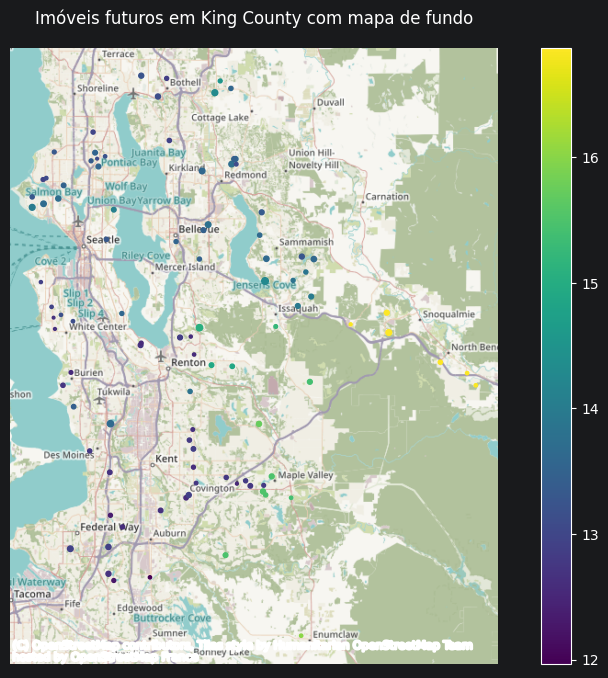

In [132]:
# Mapa das futuras casas

resultado_future["log_price"] = np.log1p(resultado_future["preco_previsto"])

gdf = gpd.GeoDataFrame(
    resultado_future,
    geometry=gpd.points_from_xy(resultado_future["long"], resultado_future["lat"]),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

ax = gdf.plot(
    column="log_price",
    markersize=gdf["sqft_living"] / 200,
    cmap="viridis",
    legend=True,
    figsize=(11, 8)
)

cx.add_basemap(ax)

plt.title("Imóveis futuros em King County com mapa de fundo")
plt.axis("off")
plt.savefig("imagens/mapa_futuras_casas.png")
plt.show()